# Ayudantía 6 ~ Aplicar los contenidos de modelos predictivos (IIC2115) #
Nicolás Olate Orellana | nicolas.olate@uc.cl 

26 de Septiembre, 2024.

# Definiciones y objetivo de ayudantía: #

## ¿Qué es el Machine Learning? ##
Machine Learning es una rama de la inteligencia artificial que se enfoca en desarrollar algoritmos capaces de **aprender automáticamente** a partir de los datos y mejorar su rendimiento sin necesidad de ser programados explícitamente para cada tarea. El objetivo de estos algoritmos es detectar patrones en los datos para luego hacer **predicciones** o **decisiones** basadas en nueva información.

## Componentes claves de ML: #
 -  **Datos**: Los modelos de ML necesitan datos para aprender. Estos datos suelen estar compuestos por características (o atributos) que describen el problema, y en algunos casos, etiquetas que representan las respuestas correctas. 

 -  **Modelos**: Los algoritmos procesan los datos para construir modelos matemáticos que puedan hacer predicciones sobre datos nuevos

 -  **Entrenamiento**: El modelo se entrena con un conjunto de datos de ejemplo, ajustando sus parámetros para mejorar su precisión.
 
 -  **Generalización**: Un buen modelo de ML es capaz de generalizar su aprendizaje a datos no vistos, es decir, funciona bien no solo en los datos de entrenamiento, sino también en nuevos datos.

## Tipos de Machine Learning: ##

### *Aprendizaje supervisado*:  
El modelo se entrena con datos etiquetados (donde las respuestas son conocidas).  
**Por ejemplo**:  
En un sistema de **control de tráfico urbano**, se entrena un modelo para predecir el **flujo de vehículos** en distintas intersecciones utilizando datos históricos de tráfico, tiempo y eventos (como festivales o deportes). Las etiquetas serían la cantidad de vehículos que han cruzado la intersección en un tiempo específico, lo que permite optimizar los tiempos de los semáforos, reduciendo así los embotellamientos.

### *Aprendizaje no supervisado*:  
El modelo trabaja con datos no etiquetados, buscando patrones ocultos.  
**Por ejemplo**:  
En un **aeropuerto**, se pueden utilizar algoritmos de clustering para analizar el movimiento de pasajeros sin etiquetas predefinidas. El modelo puede identificar **patrones de congestión** en áreas específicas (como zonas de espera o tiendas), ayudando a mejorar el diseño de las instalaciones o la disposición de los servicios para mejorar la experiencia del usuario y optimizar los flujos de pasajeros.

## Definiciones adicionales: ##
### *Etiquetas*:  
Las etiquetas se utilizan en tareas de clasificación para entrenar modelos que puedan predecir a qué categoría pertenece una nueva observación basada en sus características.
### *Clustering*:
**Clustering** (o **agrupamiento**) es una técnica de aprendizaje no supervisado en la que se agrupan las observaciones en grupos o clústeres basados en características similares, sin tener etiquetas predefinidas. El objetivo del clustering es descubrir la estructura subyacente de los datos dividiéndolos en grupos en los que las observaciones dentro de un mismo grupo son más similares entre sí que con las observaciones de otros grupos.


## Objetivo de ayudantía: ##
Aplicar los conceptos teóricos a problemas prácticos en Python, utilizando bibliotecas como Pandas, scikit-learn y técnicas de Machine Learning (ML).

## 1- Análisis de datos: ##
Se trata de limpiar, transformar, explorar, calcular estadísticas, visualizar los datos y construir modelos predictivos. Las herramientas principales son Pandas para el manejo de datos y scikit-learn para los modelos.

## 2- Machine Learning (ML): ## 

Es el uso de algoritmos para realizar tareas predictivas (clasificación, regresión, clustering, etc.).
En el aprendizaje supervisado, el modelo se entrena con un conjunto de datos con características y etiquetas (objetivo), y se busca predecir la etiqueta de nuevos datos.
## 3- scikit-learn: ##
Biblioteca de Python que implementa múltiples algoritmos de Machine Learning y se integra fácilmente con Pandas y NumPy.
El proceso típico incluye:

* Elegir un modelo (por ejemplo, regresión, árboles de decisión, k-NN).
* Entrenar el modelo con fit(X, y).
* Evaluar el modelo con datos de prueba.

## 4- Evaluación del modelo: ## 

La capacidad de generalización es clave para evitar el sobreajuste o subajuste. Se deben usar métricas como precision, recall, accuracy, y error cuadrático medio.



# Misión 1: Carga y limpieza de los datos # 
* **Carga de archivos CSV**: Usar Pandas para cargar los datos como se ha visto anteriormente.

In [65]:
import pandas as pd
data = pd.read_csv('data_E3.csv')
data.head()  # Para ver las primeras filas de los datos



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [66]:
# Muestra el número de filas y columnas en el DataFrame
num_filas, num_columnas = data.shape  # shape devuelve una tupla (número de filas, número de columnas)
print(f'Número de filas: {num_filas}')  # Imprime el número de filas
print(f'Número de columnas: {num_columnas}')  # Imprime el número de columnas

Número de filas: 20640
Número de columnas: 10


* **Limpieza de datos**:
Completar valores numéricos faltantes usando promedios y eliminar filas con datos faltantes en columnas categóricas.\
(Recordemos que las variables categóricas, son literalmente categorías y no valores numéricos)

In [67]:
# Calcula cuántas filas tienen valores faltantes (NaN) en cualquier columna
nan_counts = data.isna().sum()  # isna() retorna un DataFrame de booleanos (True si hay NaN) y sum() cuenta cuántos True hay por columna

# Imprime la cantidad de valores NaN por columna
print(nan_counts)

# Cuenta cuántas filas tienen al menos un valor NaN en cualquier columna
nan_rows = data.isna().any(axis=1).sum()  # any(axis=1) devuelve True si al menos una columna tiene NaN en esa fila, sum() cuenta esos True

# Imprime cuántas filas tienen algún valor NaN
print(f'Filas con al menos un valor NaN: {nan_rows}')

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Filas con al menos un valor NaN: 207


Imputación usando la media o la mediana:

Utilizado cuando los valores faltantes no son muchos en comparación con el total de filas y los datos numéricos son distribuidos

In [68]:


# Seleccionar solo las columnas numéricas que necesitan ser procesadas
numeric_columns = ['total_bedrooms']  # Lista de columnas numéricas

# Calcular la media de cada columna numérica
means = data[numeric_columns].mean()  # Calcula el promedio de cada columna en la lista de columnas numéricas

# Rellenar los valores faltantes (NaN) en las columnas numéricas con el promedio calculado
data[numeric_columns] = data[numeric_columns].fillna(means)  # fillna() reemplaza los NaNs con el valor de la media calculada

# Verifica que no haya más NaNs en las columnas numéricas después de la imputación
print(data[numeric_columns].isna().sum())  # Muestra el número de NaNs restantes en las columnas numéricas

total_bedrooms    0
dtype: int64


In [69]:
# Muestra el número de filas y columnas en el DataFrame
num_filas, num_columnas = data.shape  # shape devuelve una tupla (número de filas, número de columnas)
print(f'Número de filas: {num_filas}')  # Imprime el número de filas
print(f'Número de columnas: {num_columnas}')  # Imprime el número de columnas
print(data['total_bedrooms'].isna().sum())

Número de filas: 20640
Número de columnas: 10
0


# Misión 2:  Análisis visual

Primero, importaremos matplotlib y seaborn para realizar las visualizaciones

In [70]:
# Importación de bibliotecas para visualización
import matplotlib.pyplot as plt
import seaborn as sns  # Recomendado para gráficos más estilizados
import pandas as pd

# Descripción de la misión:
# En este análisis visual, exploraremos las relaciones entre las características de los datos y 
# el valor medio de las viviendas (median_house_value), usando gráficos de dispersión y boxplots.
# También analizaremos si existen patrones claros y presencia de outliers en los datos.


El análisis se basa en las relaciones entre las características y el valor medio de las viviendas (median_house_value), que utilizaremos como el color de los marcadores.

* Vamos a hacer gráficos de dispersión entre diferentes pares de variables

* Por ejemplo, analizamos la relación entre medianIncome (Ingreso medio) y medianHouseValue (Valor de la vivienda)

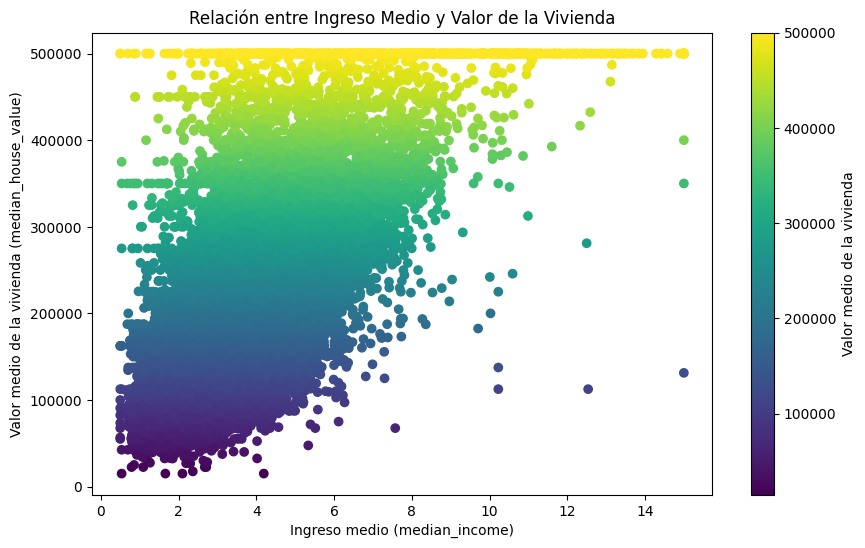

In [71]:
plt.figure(figsize=(10, 6))
# Crear gráfico de dispersión con color basado en median_house_value
sc = plt.scatter(data['median_income'], data['median_house_value'], 
                 c=data['median_house_value'], cmap='viridis')

# Agregar barra de colores y etiquetas
plt.colorbar(sc, label='Valor medio de la vivienda')
plt.xlabel('Ingreso medio (median_income)')
plt.ylabel('Valor medio de la vivienda (median_house_value)')
plt.title('Relación entre Ingreso Medio y Valor de la Vivienda')

# Mostrar gráfico
plt.show()


Este gráfico muestra la relación entre el ingreso medio (median_income) y el valor de las viviendas (median_house_value). Cada punto representa un distrito, y el color indica el valor medio de las viviendas en ese distrito.

* Grupos: Se observa una relación positiva, donde un mayor ingreso medio tiende a asociarse con un mayor valor de las viviendas. Los distritos con mayor ingreso muestran casas de mayor valor (colores más oscuros).


### 2. Gráfico de dispersión entre total_rooms y median_house_value

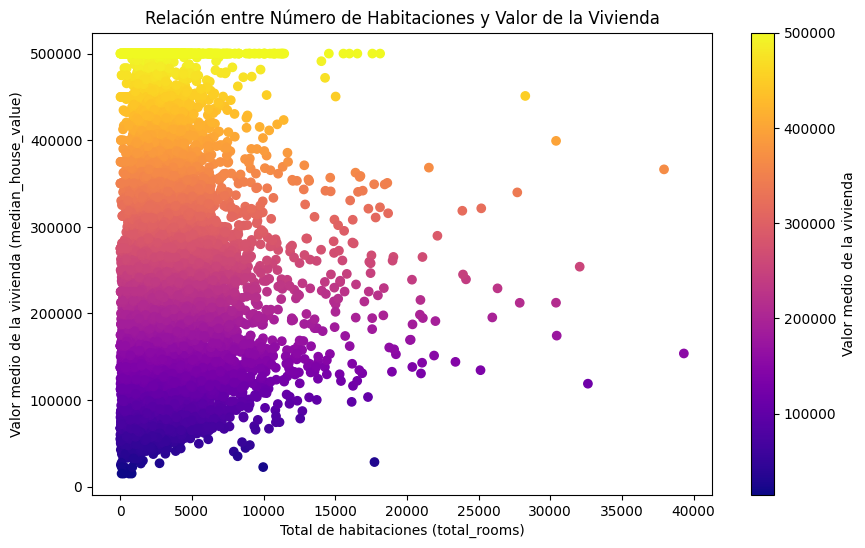

In [72]:
plt.figure(figsize=(10, 6))
# Crear gráfico de dispersión para total_rooms vs median_house_value
sc = plt.scatter(data['total_rooms'], data['median_house_value'], 
                 c=data['median_house_value'], cmap='plasma')

# Agregar barra de colores y etiquetas
plt.colorbar(sc, label='Valor medio de la vivienda')
plt.xlabel('Total de habitaciones (total_rooms)')
plt.ylabel('Valor medio de la vivienda (median_house_value)')
plt.title('Relación entre Número de Habitaciones y Valor de la Vivienda')

# Mostrar gráfico
plt.show()


Análisis: Aquí se muestra la relación entre el número total de habitaciones en un distrito (total_rooms) y el valor de las viviendas (median_house_value).
* En este gráfico, no se observa una relación lineal clara entre el número de habitaciones y el valor de las viviendas. Podría sugerir que el tamaño o número de habitaciones no es un predictor tan fuerte del valor de la vivienda como lo es el ingreso medio.

### 3. Boxplot de median_house_value para detectar outliers

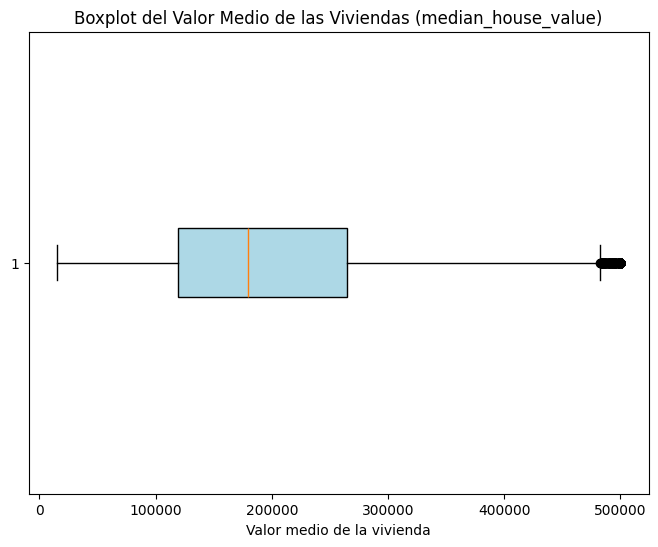

In [73]:
plt.figure(figsize=(8, 6))
# Crear boxplot para el valor medio de las viviendas
plt.boxplot(data['median_house_value'], vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightblue'))

plt.title('Boxplot del Valor Medio de las Viviendas (median_house_value)')
plt.xlabel('Valor medio de la vivienda')
plt.show()


Análisis: El boxplot te permite visualizar la distribución del valor medio de las viviendas y buscar valores atípicos (outliers).
* En este gráfico, cualquier punto que esté muy alejado de la caja central (rango intercuartil) será considerado un outlier. Los valores muy altos o muy bajos que se encuentran fuera de este rango representan distritos con precios de viviendas atípicos, comparados con el resto de los distrito

# Misión 3: Análisis de clusters

Paso 1: Preparación de los datos para clustering


Primero necesitamos preparar los datos de dos formas diferentes:

- Espacio de características (sin etiqueta): Usaremos solo las características numéricas.
- Espacio completo (con la etiqueta): Aquí añadiremos la etiqueta (median_house_value) como una característica más.

Primero, aseguramos que los datos numéricos estén correctamente normalizados, ya que el clustering con K-means se ve afectado por la escala de las características.

In [74]:
from sklearn.preprocessing import StandardScaler

# Seleccionamos las características numéricas
features = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

# Normalizamos las características numéricas
scaler = StandardScaler()
X_features = scaler.fit_transform(data[features])

# También incluimos la etiqueta en un segundo conjunto
X_complete = scaler.fit_transform(data[features + ['median_house_value']])


### Paso 2: Método del codo para encontrar el número óptimo de clusters
Para encontrar el número óptimo de clusters, usaremos el método del codo, que mide la "inercia" o "dentro del grupo suma de cuadrados" para diferentes números de clusters y selecciona el valor donde la inercia comienza a disminuir de manera menos pronunciada.

2.1 Clustering sobre el espacio de características (sin la etiqueta):

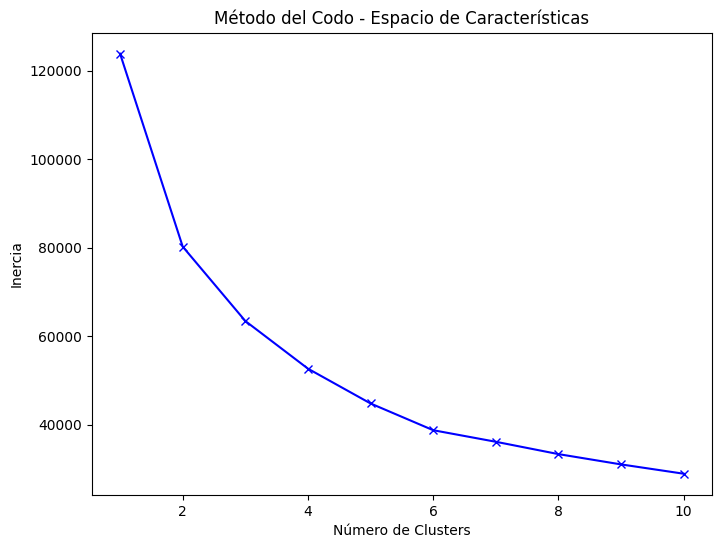

In [75]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Probar varios números de clusters
inertia = []
K_range = range(1, 11)  # Probar entre 1 y 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_features)
    inertia.append(kmeans.inertia_)

# Gráfico del método del codo
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo - Espacio de Características')
plt.show()


# Método del codo para identificar el número óptimo de clusters
# Inercia representa la suma de las distancias cuadradas de cada punto a su centroide más cercano.
# Cuanto menor es la inercia, más compactos están los clusters.

2.2 Clustering sobre el espacio completo (con la etiqueta):

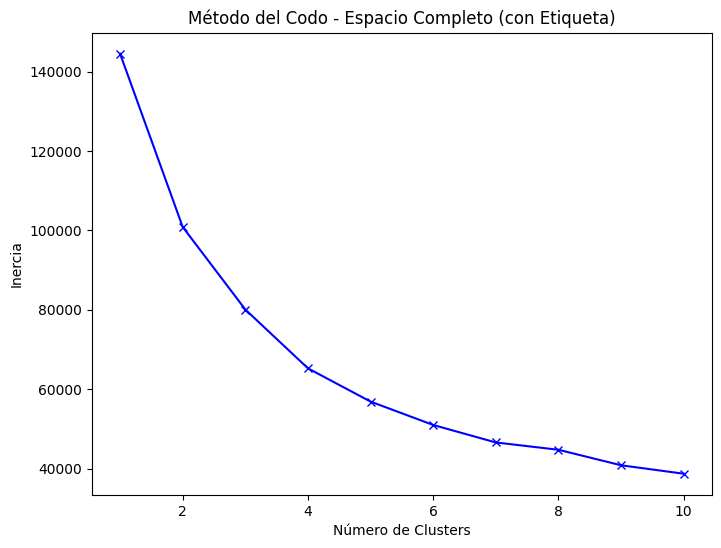

In [76]:
inertia_complete = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_complete)
    inertia_complete.append(kmeans.inertia_)

# Gráfico del método del codo
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia_complete, 'bx-')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo - Espacio Completo (con Etiqueta)')
plt.show()





### Paso 3: Aplicar el clustering óptimo

Una vez que hayas identificado el número óptimo de clusters (normalmente donde el gráfico del codo empieza a doblarse), podemos aplicar K-means para ese número de clusters.

3.1 Clustering con el número óptimo sobre el espacio de características:

In [77]:
# Asumamos que el número óptimo es 4 (cambiar según el gráfico del codo)
optimal_k = 4

kmeans_features = KMeans(n_clusters=optimal_k, random_state=0)
clusters_features = kmeans_features.fit_predict(X_features)

# Agregar las etiquetas de cluster a los datos originales
data['cluster_features'] = clusters_features


3.2 Clustering con el número óptimo sobre el espacio completo:

In [78]:
kmeans_complete = KMeans(n_clusters=optimal_k, random_state=0)
clusters_complete = kmeans_complete.fit_predict(X_complete)

# Agregar las etiquetas de cluster al espacio completo
data['cluster_complete'] = clusters_complete


#### Paso 4: Visualización de los clusters

Ahora visualizaremos los clusters para comparar cómo cambian cuando usamos el espacio de características sin la etiqueta vs. con la etiqueta.

4.1 Visualización del clustering en el espacio de características:

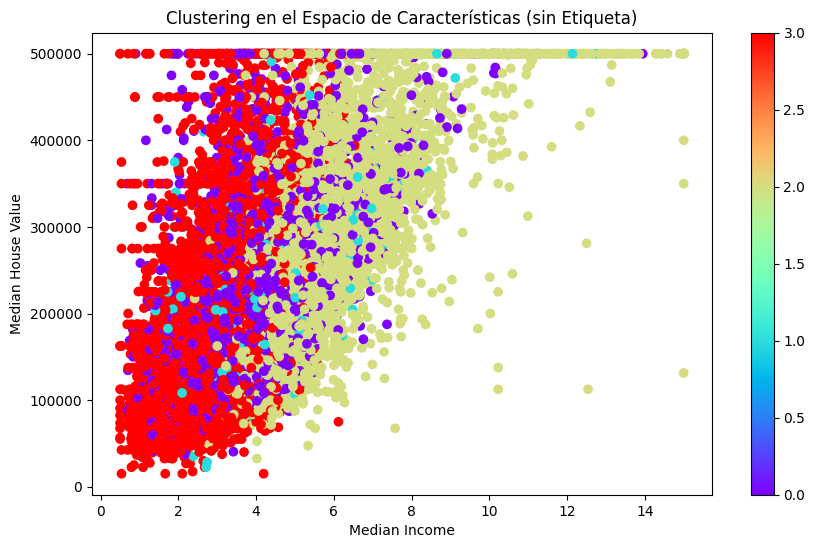

In [96]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(data['median_income'], data['median_house_value'], c=data['cluster_features'], cmap='rainbow')
plt.colorbar(sc)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Clustering en el Espacio de Características (sin Etiqueta)')
plt.show()

# Análisis:
# En este gráfico, observamos que los clusters se forman basándose en las características subyacentes,
# como el ingreso medio, pero no tienen en cuenta directamente el valor de la vivienda.

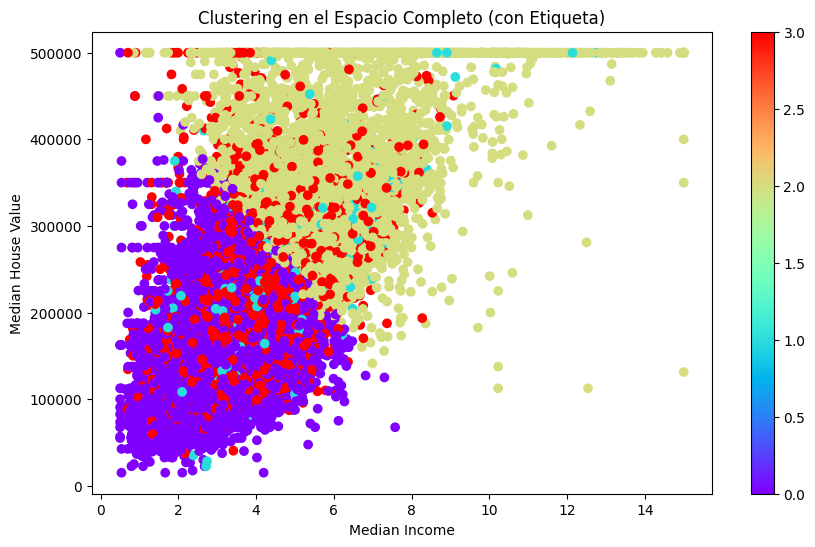

In [97]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(data['median_income'], data['median_house_value'], c=data['cluster_complete'], cmap='rainbow')
plt.colorbar(sc)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Clustering en el Espacio Completo (con Etiqueta)')
plt.show()


* En ambos análisis de clusters, se pueden observar agrupaciones de datos basadas en ciertas características, como median_income y median_house_value, que ayudan a diferenciar los distritos de acuerdo con el valor de las viviendas.
* El clustering basado en el espacio de características tiende a agrupar los datos en función de las variables sin influencia directa de la etiqueta (median_house_value), creando grupos que reflejan las diferencias en características como el ingreso o el número de habitaciones.
#### Diferencias:
* El clustering en el espacio completo (con la etiqueta) probablemente agrupe de manera más marcada las viviendas de alto valor en un cluster distinto. Esto ocurre porque la etiqueta influye directamente en el proceso de clustering, haciendo que los datos se agrupen de acuerdo con los valores de las viviendas más que solo en base a las características subyacentes.
* En el clustering sin la etiqueta, puede haber más solapamiento entre los grupos de datos, ya que se basa solo en las características.
#### Conclusión:
El uso de la etiqueta en el clustering tiende a generar grupos más definidos en función del precio de las viviendas, lo que resalta cómo la inclusión de la variable objetivo afecta el proceso.
Sin la etiqueta, los clusters están más dispersos y tienden a reflejar las diferencias entre las características subyacentes, sin un enfoque específico en el precio de las viviendas.

# Misión 4: Predicción de la etiqueta

### 1: Predicción Tradicional

Entrenaremos modelos predictivos para predecir directamente la etiqueta (median_house_value), utilizando tres familias distintas de modelos.

Para este caso, vamos a probar tres familias distintas de modelos:

* Regresión Lineal (LinearRegression)
* Árbol de Decisión (DecisionTreeRegressor)
* Random Forest (RandomForestRegressor)

Dividir los datos en entrenamiento y prueba
* Usamos la columna median_house_value como etiqueta y las demás columnas numéricas como características.

In [81]:
from sklearn.model_selection import train_test_split

# Separar las características y la etiqueta
X = data[['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']]
y = data['median_house_value']

# Dividir los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Paso 2: Entrenamiento de los modelos 
* 2.1 Regresión Lineal

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Entrenar el modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Hacer predicciones
y_pred_lin = lin_reg.predict(X_test)

# Evaluar el rendimiento
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"Regresión Lineal - MSE: {mse_lin}, R2: {r2_lin}")


Regresión Lineal - MSE: 5963976459.53363, R2: 0.5448767095949155



* 2.2 Árbol de Decisión

In [83]:
from sklearn.tree import DecisionTreeRegressor

# Entrenar el modelo
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# Hacer predicciones
y_pred_tree = tree_reg.predict(X_test)

# Evaluar el rendimiento
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Árbol de Decisión - MSE: {mse_tree}, R2: {r2_tree}")


Árbol de Decisión - MSE: 9105555638.32849, R2: 0.3051363513586548


* 2.3 Random Forest

In [84]:
from sklearn.ensemble import RandomForestRegressor

# Entrenar el modelo
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train, y_train)

# Hacer predicciones
y_pred_forest = forest_reg.predict(X_test)

# Evaluar el rendimiento
mse_forest = mean_squared_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print(f"Random Forest - MSE: {mse_forest}, R2: {r2_forest}")


Random Forest - MSE: 4812351673.215778, R2: 0.6327595618525214


## 2: Predicción con Reducción de Dimensionalidad

Usaremos PCA (Análisis de Componentes Principales) para reducir las dimensiones de los datos y entrenaremos los modelos en espacios reducidos.

 #### Aplicar PCA
Probaremos con 3 tamaños diferentes de espacios de características reducidos: 2, 3 y 5 componentes

In [85]:
from sklearn.decomposition import PCA

# Reducción a 2 componentes
pca_2 = PCA(n_components=2)
X_train_pca_2 = pca_2.fit_transform(X_train)
X_test_pca_2 = pca_2.transform(X_test)

# Reducción a 3 componentes
pca_3 = PCA(n_components=3)
X_train_pca_3 = pca_3.fit_transform(X_train)
X_test_pca_3 = pca_3.transform(X_test)

# Reducción a 5 componentes
pca_5 = PCA(n_components=5)
X_train_pca_5 = pca_5.fit_transform(X_train)
X_test_pca_5 = pca_5.transform(X_test)


Paso 2: Entrenamiento de modelos en los espacios reducidos

 Regresión Lineal, Árbol de Decisión y Random Forest en cada uno de estos espacios.

2.1 Regresión Lineal con 2 componentes

In [86]:
lin_reg.fit(X_train_pca_2, y_train)
y_pred_pca_2 = lin_reg.predict(X_test_pca_2)
mse_pca_2 = mean_squared_error(y_test, y_pred_pca_2)
r2_pca_2 = r2_score(y_test, y_pred_pca_2)
print(f"Regresión Lineal con 2 componentes - MSE: {mse_pca_2}, R2: {r2_pca_2}")


Regresión Lineal con 2 componentes - MSE: 12006075596.239103, R2: 0.08379171727317347


2.2 Árbol de Decisión con 3 componentes

In [87]:
tree_reg.fit(X_train_pca_3, y_train)
y_pred_pca_3 = tree_reg.predict(X_test_pca_3)
mse_pca_3 = mean_squared_error(y_test, y_pred_pca_3)
r2_pca_3 = r2_score(y_test, y_pred_pca_3)
print(f"Árbol de Decisión con 3 componentes - MSE: {mse_pca_3}, R2: {r2_pca_3}")


Árbol de Decisión con 3 componentes - MSE: 18235917640.229893, R2: -0.39162032182577766


2.3 Random Forest con 5 componentes

In [88]:
forest_reg.fit(X_train_pca_5, y_train)
y_pred_pca_5 = forest_reg.predict(X_test_pca_5)
mse_pca_5 = mean_squared_error(y_test, y_pred_pca_5)
r2_pca_5 = r2_score(y_test, y_pred_pca_5)
print(f"Random Forest con 5 componentes - MSE: {mse_pca_5}, R2: {r2_pca_5}")


Random Forest con 5 componentes - MSE: 8257284594.481747, R2: 0.3698696566039733


Según los resultados, el modelo Random Forest entrenado con el espacio de características completo tuvo el mejor rendimiento con un MSE (error cuadrado medio mas bajo, mas cercano a valores reales) de 4812351673.21 y un R² de 0.63276. Ahora procederemos a realizar un proceso de selección de características para construir un ranking de las más informativas.

# Misión 5: Ranking de mejores características:

## Paso 1: Entrenar el modelo de Random Forest
Usaremos el modelo de Random Forest que ya obtuviste, pero agregaremos un análisis de importancia de características. Random Forest tiene un atributo llamado feature_importances_ que mide la importancia de cada característica.

In [89]:
# Entrenar el modelo nuevamente (si es necesario)
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train, y_train)

# Obtener las importancias de las características
importances = forest_reg.feature_importances_

# Crear un DataFrame para organizar las importancias
feature_names = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Ordenar las características por importancia
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


              Feature  Importance
5       median_income    0.565650
3          population    0.104195
0  housing_median_age    0.098074
2      total_bedrooms    0.089217
1         total_rooms    0.073188
4          households    0.069675


Puedes visualizar fácilmente las importancias con un gráfico de barras para destacar las más informativas.

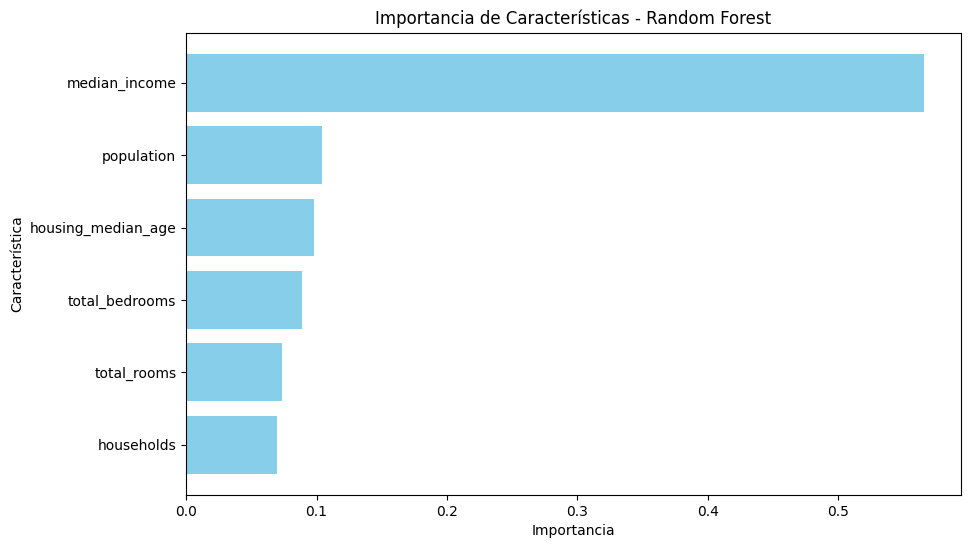

In [90]:
# Visualización de la importancia de las características
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Importancia de Características - Random Forest')
plt.gca().invert_yaxis()  # Invertir el eje para que la característica más importante aparezca arriba
plt.show()


median_income suele ser una de las características más importantes en la predicción del valor de las viviendas.

# Misión 6: Nuevas características:

1. Carga de las nuevas características: Vamos a incluir las columnas longitude y latitude en el análisis.

2. Repetición de la limpieza de datos: Aplicaremos los mismos procesos de limpieza, como el manejo de valores faltantes, con las nuevas variables.

3. Repetición del análisis de visualización y clusters: Realizaremos gráficos de dispersión y clustering, incluyendo longitude y latitude.

4. Repetición de la predicción con las nuevas variables: Entrenaremos los modelos predictivos (Regresión Lineal, Árbol de Decisión y Random Forest) y verificaremos cómo afectan las nuevas características al rendimiento.

In [91]:
# Verifica si longitude y latitude están en el DataFrame
if 'longitude' in data.columns and 'latitude' in data.columns:
    print('Longitude y Latitude ya están en los datos.')
else:
    print('No se encuentran las columnas longitude y latitude.')

# Verifica valores faltantes en longitude y latitude
nan_counts_new = data[['longitude', 'latitude']].isna().sum()
print(f"Valores NaN en longitude y latitude: \n{nan_counts_new}")

# Rellenar valores faltantes en longitude y latitude con la media (si hay NaN)
means_new = data[['longitude', 'latitude']].mean()
data[['longitude', 'latitude']] = data[['longitude', 'latitude']].fillna(means_new)

# Verifica que no haya NaNs restantes
print(data[['longitude', 'latitude']].isna().sum())


Longitude y Latitude ya están en los datos.
Valores NaN en longitude y latitude: 
longitude    0
latitude     0
dtype: int64
longitude    0
latitude     0
dtype: int64


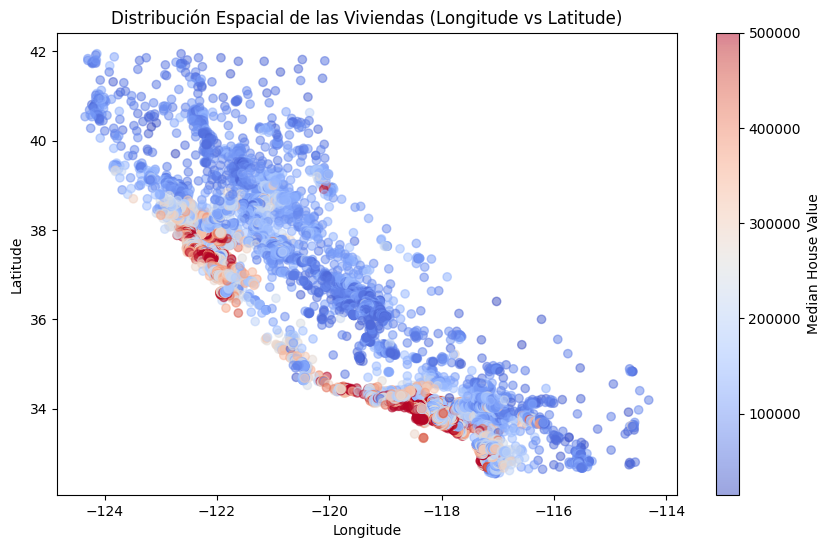

In [92]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(data['longitude'], data['latitude'], c=data['median_house_value'], cmap='coolwarm', alpha=0.5)
plt.colorbar(sc, label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Distribución Espacial de las Viviendas (Longitude vs Latitude)')
plt.show()


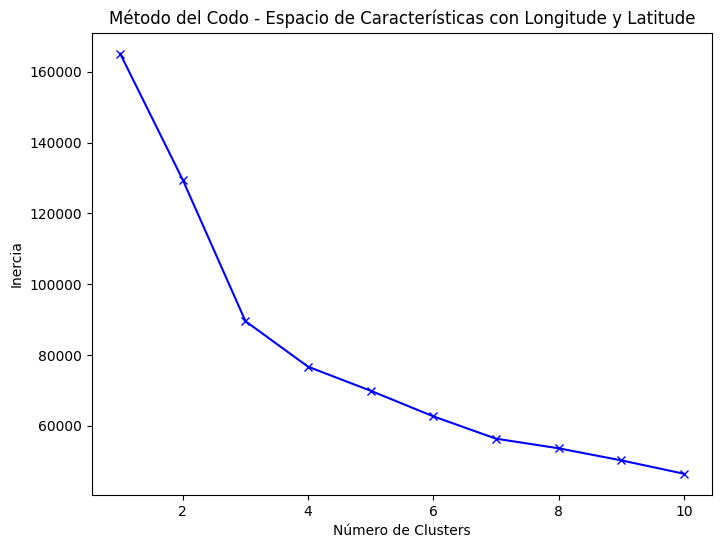

In [93]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Añadir longitude y latitude a las características
features_new = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'longitude', 'latitude']

# Normalizamos las características numéricas
scaler = StandardScaler()
X_features_new = scaler.fit_transform(data[features_new])

# Método del codo para encontrar el número óptimo de clusters
inertia_new = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_features_new)
    inertia_new.append(kmeans.inertia_)

# Gráfico del método del codo con las nuevas características
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia_new, 'bx-')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo - Espacio de Características con Longitude y Latitude')
plt.show()


In [94]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Separar las características y la etiqueta (incluyendo longitude y latitude)
X_new = data[features_new]
y = data['median_house_value']

# Dividir los datos en entrenamiento y prueba
X_train_new, X_test_new, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Entrenar y evaluar los modelos con las nuevas características

# Regresión Lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train_new, y_train)
y_pred_lin_new = lin_reg.predict(X_test_new)
mse_lin_new = mean_squared_error(y_test, y_pred_lin_new)
r2_lin_new = r2_score(y_test, y_pred_lin_new)
print(f"Regresión Lineal - MSE: {mse_lin_new}, R2: {r2_lin_new}")

# Árbol de Decisión
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_new, y_train)
y_pred_tree_new = tree_reg.predict(X_test_new)
mse_tree_new = mean_squared_error(y_test, y_pred_tree_new)
r2_tree_new = r2_score(y_test, y_pred_tree_new)
print(f"Árbol de Decisión - MSE: {mse_tree_new}, R2: {r2_tree_new}")

# Random Forest
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train_new, y_train)
y_pred_forest_new = forest_reg.predict(X_test_new)
mse_forest_new = mean_squared_error(y_test, y_pred_forest_new)
r2_forest_new = r2_score(y_test, y_pred_forest_new)
print(f"Random Forest - MSE: {mse_forest_new}, R2: {r2_forest_new}")


Regresión Lineal - MSE: 5052953703.901627, R2: 0.6143987268246025
Árbol de Decisión - MSE: 4887352045.346172, R2: 0.6270361294451003
Random Forest - MSE: 2487911386.756345, R2: 0.810142373253873


              Feature  Importance
5       median_income    0.520714
6           longitude    0.156237
7            latitude    0.146104
0  housing_median_age    0.065976
3          population    0.037807
2      total_bedrooms    0.028402
1         total_rooms    0.024685
4          households    0.020074


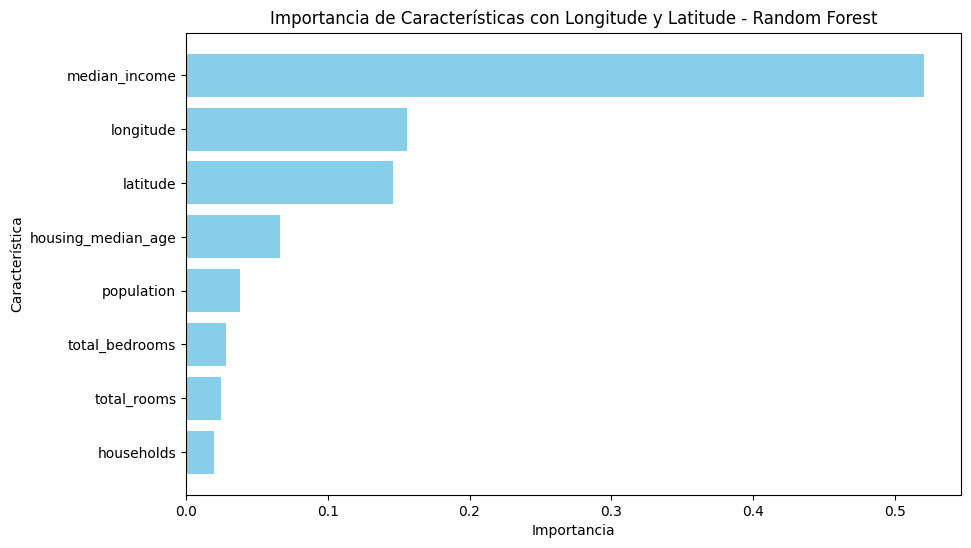

In [95]:
# Importancia de las características con longitude y latitude
importances_new = forest_reg.feature_importances_

# Crear un DataFrame para organizar las importancias
importance_df_new = pd.DataFrame({'Feature': features_new, 'Importance': importances_new})

# Ordenar las características por importancia
importance_df_new = importance_df_new.sort_values(by='Importance', ascending=False)
print(importance_df_new)

# Visualizar la importancia de las características
plt.figure(figsize=(10, 6))
plt.barh(importance_df_new['Feature'], importance_df_new['Importance'], color='skyblue')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Importancia de Características con Longitude y Latitude - Random Forest')
plt.gca().invert_yaxis()
plt.show()


Influencia espacial: Al agregar longitude y latitude, es probable que los modelos detecten patrones geográficos que no eran evidentes antes.
Cambio en la importancia: Esperamos que longitude y latitude sean importantes en la predicción, especialmente si hay una fuerte correlación espacial con los precios de las viviendas.
Mejora en la predicción: Es posible que los modelos mejoren su rendimiento (mayor R² y menor MSE) al tener en cuenta la ubicación geográfica.